 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500,006/500,000  [ 0:53:00 < 0:00:00 , 156 it/s ]


  Evaluating on locked test season...

  Results — 2024/25:
  Agent                          Mean PnL   Sharpe    %Pos      MaxDD
  ----------------------------------------------------------------
  PPO                               44.79   0.5860   76.7%   -1899.98
  DDPG                              -9.19  -0.1893   17.4%  -18037.28
  Mean Reversion (Oracle)           39.41   0.4953   72.4%   -3727.92
  Naive Hold                        -1.21  -0.0146   47.7%   -4182.94


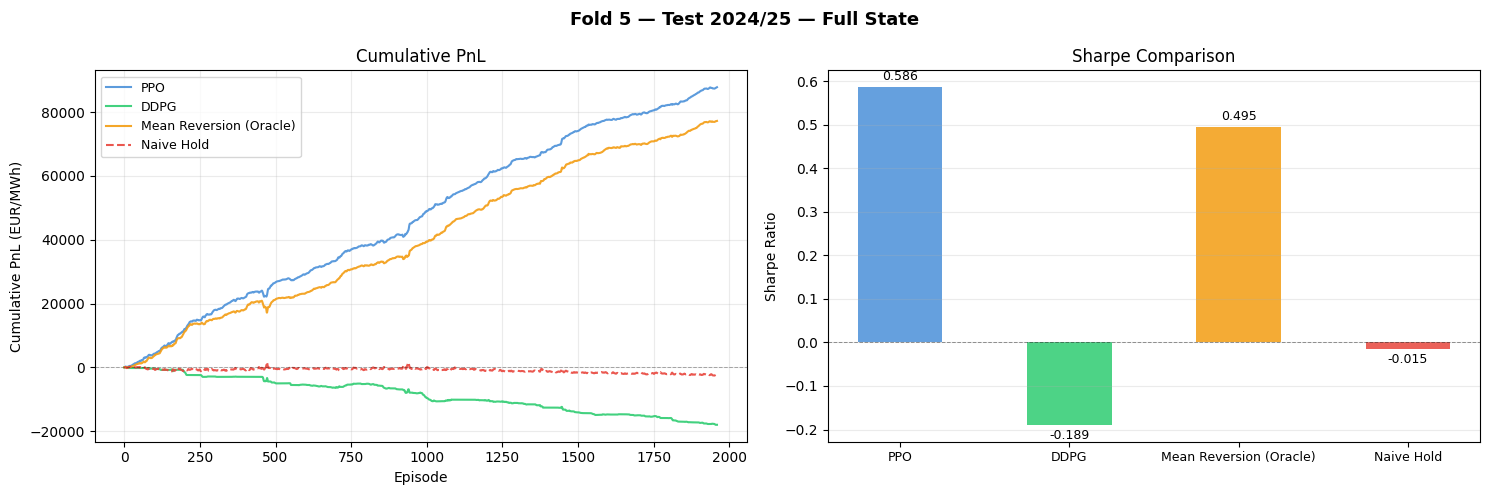

Outer folds: 100%|██████████| 5/5 [13:37:21<00:00, 9808.31s/fold]

  Saved /content/drive/MyDrive/MEng Project/s1_fold_2024_25.png
  Checkpoint saved — 5/5 folds complete.

FULL STATE — FINAL SUMMARY
   Fold                   Agent  Mean PnL  Sharpe  % Positive      Max DD
2020/21                     PPO   15.4312  0.5327        75.4   -504.8338
2020/21                    DDPG   -6.0205 -0.2065        34.6 -13105.4019
2020/21 Mean Reversion (Oracle)   12.5956  0.4579        66.9   -434.6992
2020/21              Naive Hold   -0.9636 -0.0345        45.8  -2101.0513
2021/22                     PPO    6.2782  0.0957        54.4  -1607.8694
2021/22                    DDPG   -3.9517 -0.0626        46.1  -9717.7751
2021/22 Mean Reversion (Oracle)   12.2773  0.2203        55.1   -925.3993
2021/22              Naive Hold   -1.0753 -0.0170        47.7  -3102.6311
2022/23                     PPO   37.2501  0.5381        74.1   -791.4305
2022/23                    DDPG  -10.7869 -0.1581        44.0 -21642.7561
2022/23 Mean Reversion (Oracle)   31.6616  0.4403    


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:

# SCRIPT 1 — Full State Nested CV Walk-Forward (GARCH)
#
# For each fold:
#   Inner loop: tune PPO + DDPG on season 1, validate on season 2
#   Outer loop: retrain best config on both seasons, test on locked season
#
# Saves per fold:
#   - Checkpoint JSON after every fold
#   - Per-fold plots
#   - Selected hyperparameters
#   - Raw PnL lists + action counts
#
# State: price_da_norm, price_id_norm, spread_norm, sigma_norm,
#        wind_norm, load_norm, ttd_norm, wfe_norm, position

# Highly computationally demanding - expect runtimes of 12+ hours if not using high-end hardware

!pip install arch stable-baselines3 gymnasium entsoe-py tqdm -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from arch import arch_model
from stable_baselines3 import PPO, DDPG
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from entsoe import EntsoePandasClient
from tqdm import tqdm
import gymnasium as gym
from gymnasium import spaces
import json, os, torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ─────────────────────────────────────────────
# 0. CONFIG
# ─────────────────────────────────────────────
DRIVE_PATH  = "/content/drive/MyDrive/MEng Project"
API_KEY     = "[REDACTED]"
CHECKPOINT  = f"{DRIVE_PATH}/s1_full_results.json"

TUNING_STEPS = 50_000
TRAIN_STEPS  = 500_000
MR_THRESHOLD = 0.5

PPO_GRID = [
    {"learning_rate": lr, "n_steps": ns}
    for lr in [0.001, 0.0003]
    for ns in [512, 1024, 2048]
]
DDPG_GRID = [
    {"learning_rate": lr, "batch_size": bs, "action_threshold": thr}
    for lr  in [0.003, 0.001]
    for bs  in [128, 256]
    for thr in [0.2, 0.33, 0.5]
]

FOLDS = [
    (["2018/19", "2019/20"], "2020/21"),
    (["2019/20", "2020/21"], "2021/22"),
    (["2020/21", "2021/22"], "2022/23"),
    (["2021/22", "2022/23"], "2023/24"),
    (["2022/23", "2023/24"], "2024/25"),
]

ALL_SEASONS = sorted(set(s for fold in FOLDS for s in fold[0] + [fold[1]]))

SEASON_DATES = {
    "2019/20": ("20191001", "20200301"),
    "2020/21": ("20201001", "20210301"),
    "2021/22": ("20211001", "20220301"),
    "2022/23": ("20221001", "20230301"),
    "2023/24": ("20231001", "20240301"),
    "2024/25": ("20241001", "20250301"),
}

STATE_FEATURES = [
    "price_da_norm",
    "price_id_norm",
    "spread_norm",    # index 2 — used by mean reversion oracle
    "sigma_norm",
    "wind_norm",
    "load_norm",
    "ttd_norm",
    "wfe_norm",
]

WINDOW_STEPS     = 15
MAX_POSITION     = 1
TRANSACTION_COST = 0.1
CLOSEOUT_PENALTY = 1.0
SIGMA_FLOOR      = 0.5
SIGMA_CAP        = 30.0

COLOURS = {
    "PPO":                    "#4A90D9",
    "DDPG":                   "#2ECC71",
    "Mean Reversion (Oracle)":"#F39C12",
    "Naive Hold":             "#E8453C",
}


# ─────────────────────────────────────────────
# 1. DATA LOADING
# ─────────────────────────────────────────────
client = EntsoePandasClient(api_key=API_KEY)

def download_season(season):
    cache = f"{DRIVE_PATH}/wfv_season_{season.replace('/', '_')}.csv"
    if os.path.exists(cache):
        df = pd.read_csv(cache, parse_dates=["timestamp"])
        if len(df) > 0:
            print(f"  {season}: loaded from cache ({len(df)} rows)")
            return df
        os.remove(cache)
    print(f"  {season}: downloading...")
    s_str, e_str = SEASON_DATES[season]
    start = pd.Timestamp(s_str, tz="UTC")
    end   = pd.Timestamp(e_str, tz="UTC")
    da_raw = client.query_day_ahead_prices("10Y1001A1001A82H", start=start, end=end)
    da = da_raw.reset_index()
    da.columns = ["timestamp", "price_eur_mwh"]
    da["timestamp"] = pd.to_datetime(da["timestamp"], utc=True)
    da = da.set_index("timestamp").resample("15min").ffill().reset_index()
    sm = pd.read_csv(f"{DRIVE_PATH}/smard_fundamentals.csv", parse_dates=["timestamp"])
    sm["timestamp"] = pd.to_datetime(sm["timestamp"], utc=True)
    sm = sm[(sm["timestamp"] >= start) & (sm["timestamp"] < end)]
    df = da.merge(sm[["timestamp", "wind_total_mw", "load_mw"]], on="timestamp", how="inner")
    df["season"] = season
    df = df[df["timestamp"].dt.hour.between(11, 23)].reset_index(drop=True)
    df.to_csv(cache, index=False)
    print(f"    saved {len(df)} rows")
    return df


def download_wfe(season):
    cache = f"{DRIVE_PATH}/wfv_wfe_{season.replace('/', '_')}.csv"
    if os.path.exists(cache):
        wfe = pd.read_csv(cache, parse_dates=["timestamp"])
        if len(wfe) > 0 and "wind_forecast_mw" in wfe.columns:
            print(f"  WFE {season}: loaded from cache ({len(wfe)} rows)")
            return wfe
        if os.path.exists(cache): os.remove(cache)
    print(f"  WFE {season}: downloading...")
    s_str, e_str = SEASON_DATES[season]
    start = pd.Timestamp(s_str, tz="UTC")
    end   = pd.Timestamp(e_str, tz="UTC")
    try:
        wf_off = client.query_wind_and_solar_forecast("10Y1001A1001A82H", start=start, end=end, psr_type="B19")
        wf_on  = client.query_wind_and_solar_forecast("10Y1001A1001A82H", start=start, end=end, psr_type="B18")
        wf = pd.DataFrame({"wind_forecast_mw": wf_off.squeeze() + wf_on.squeeze()}).reset_index()
        wf.columns = ["timestamp", "wind_forecast_mw"]
        wf["timestamp"] = pd.to_datetime(wf["timestamp"], utc=True)
        wf = wf.set_index("timestamp").resample("15min").ffill().reset_index()
        wf.to_csv(cache, index=False)
        print(f"    saved {len(wf)} rows")
        return wf
    except Exception as e:
        print(f"    WARNING: WFE failed for {season}: {e}")
        return pd.DataFrame({"timestamp": pd.Series(dtype="object"),
                              "wind_forecast_mw": pd.Series(dtype="float64")})


print("=" * 60)
print("LOADING DATA")
print("=" * 60)
season_data = {}
wfe_data    = {}
for season in ALL_SEASONS:
    season_data[season] = download_season(season)
    wfe_data[season]    = download_wfe(season)
print("\nAll data ready.\n")


# ─────────────────────────────────────────────
# 2. ENVIRONMENTS
# ─────────────────────────────────────────────
class IntradayTradingEnv(gym.Env):
    def __init__(self, df, mode="train"):
        super().__init__()
        self.df   = df.reset_index(drop=True)
        self.mode = mode
        self.episode_starts = [
            i for i in self.df.index[self.df["ttd_norm"] == 1.0].tolist()
            if i + WINDOW_STEPS <= len(self.df)
        ]
        assert len(self.episode_starts) > 0, "No valid episodes"
        self.observation_space = spaces.Box(
            low=-10., high=10., shape=(len(STATE_FEATURES)+1,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(3)
        self._eval_idx = 0

    def _delta(self, a): return {0:-1, 1:0, 2:1}[int(a)]
    def _row(self):      return self.df.iloc[self._ep_start + self._step]

    def _obs(self):
        r = self._row()
        s = [float(r[f]) for f in STATE_FEATURES]
        s.append(float(self._pos) / MAX_POSITION)
        return np.nan_to_num(np.array(s, dtype=np.float32), nan=0.0, posinf=10.0, neginf=-10.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if self.mode == "train":
            self._ep_start = int(self.np_random.choice(self.episode_starts))
        else:
            self._ep_start  = self.episode_starts[self._eval_idx % len(self.episode_starts)]
            self._eval_idx += 1
        self._step = 0; self._pos = 0
        self._prev = float(self.df.iloc[self._ep_start]["p_intraday"])
        self._pnl  = 0.0
        return self._obs(), {}

    def step(self, action):
        r       = self._row()
        price   = float(r["p_intraday"])
        new_pos = int(np.clip(self._pos + self._delta(action), -MAX_POSITION, MAX_POSITION))
        traded  = new_pos != self._pos
        reward  = float(self._pos * (price - self._prev))
        if traded: reward -= TRANSACTION_COST
        self._step += 1
        done = self._step >= WINDOW_STEPS
        if done and new_pos != 0:
            reward -= abs(new_pos) * CLOSEOUT_PENALTY
        self._pos = new_pos; self._prev = price; self._pnl += reward
        obs = self._obs() if not done else np.zeros(self.observation_space.shape, dtype=np.float32)
        return obs, reward, done, False, {"ep_pnl": self._pnl}


class IntradayTradingEnvContinuous(gym.Env):
    def __init__(self, df, mode="train", action_threshold=0.5):
        super().__init__()
        self.df               = df.reset_index(drop=True)
        self.mode             = mode
        self.ACTION_THRESHOLD = action_threshold
        self.episode_starts   = [
            i for i in self.df.index[self.df["ttd_norm"] == 1.0].tolist()
            if i + WINDOW_STEPS <= len(self.df)
        ]
        assert len(self.episode_starts) > 0, "No valid episodes"
        self.observation_space = spaces.Box(
            low=-10., high=10., shape=(len(STATE_FEATURES)+1,), dtype=np.float32
        )
        self.action_space = spaces.Box(low=-1., high=1., shape=(1,), dtype=np.float32)
        self._eval_idx = 0

    def _delta(self, a):
        if   a < -self.ACTION_THRESHOLD: return -1
        elif a >  self.ACTION_THRESHOLD: return  1
        else:                            return  0

    def _row(self): return self.df.iloc[self._ep_start + self._step]

    def _obs(self):
        r = self._row()
        s = [float(r[f]) for f in STATE_FEATURES]
        s.append(float(self._pos) / MAX_POSITION)
        return np.nan_to_num(np.array(s, dtype=np.float32), nan=0.0, posinf=10.0, neginf=-10.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if self.mode == "train":
            self._ep_start = int(self.np_random.choice(self.episode_starts))
        else:
            self._ep_start  = self.episode_starts[self._eval_idx % len(self.episode_starts)]
            self._eval_idx += 1
        self._step = 0; self._pos = 0
        self._prev = float(self.df.iloc[self._ep_start]["p_intraday"])
        self._pnl  = 0.0
        return self._obs(), {}

    def step(self, action):
        a       = float(np.squeeze(action))
        r       = self._row()
        price   = float(r["p_intraday"])
        new_pos = int(np.clip(self._pos + self._delta(a), -MAX_POSITION, MAX_POSITION))
        traded  = new_pos != self._pos
        reward  = float(self._pos * (price - self._prev))
        if traded: reward -= TRANSACTION_COST
        self._step += 1
        done = self._step >= WINDOW_STEPS
        if done and new_pos != 0:
            reward -= abs(new_pos) * CLOSEOUT_PENALTY
        self._pos = new_pos; self._prev = price; self._pnl += reward
        obs = self._obs() if not done else np.zeros(self.observation_space.shape, dtype=np.float32)
        return obs, reward, done, False, {"ep_pnl": self._pnl}


# ─────────────────────────────────────────────
# 3. GARCH CALIBRATION
# ─────────────────────────────────────────────
def fit_garch(log_returns_train):
    garch = arch_model(log_returns_train, vol="Garch", p=1, q=1, dist="normal", rescale=False)
    res   = garch.fit(disp="off", options={"maxiter": 500})
    return float(res.params["omega"]), float(res.params["alpha[1]"]), float(res.params["beta[1]"])


def compute_garch_vol(log_returns, omega, alpha, beta, sigma2_init):
    n = len(log_returns); sigma2 = np.zeros(n)
    sigma2[0] = max(sigma2_init, 1e-6); vals = log_returns.values
    for t in range(1, n):
        sigma2[t] = max(omega + alpha * vals[t-1]**2 + beta * sigma2[t-1], 1e-6)
    return np.sqrt(sigma2)


# ─────────────────────────────────────────────
# 4. BUILD FOLD DATAFRAME
# ─────────────────────────────────────────────
def build_fold_df(train_seasons, test_season):
    train_raw  = pd.concat([season_data[s] for s in train_seasons]).reset_index(drop=True)
    df_full    = pd.concat([train_raw, season_data[test_season]]).sort_values("timestamp").reset_index(drop=True)
    train_mask = df_full["season"].isin(train_seasons)

    # WFE — default to zero
    df_full["wind_forecast_mw"] = np.nan
    df_full["wfe_mw"]           = 0.0
    try:
        frames = [wfe_data[s] for s in train_seasons + [test_season]
                  if len(wfe_data[s]) > 0 and "wind_forecast_mw" in wfe_data[s].columns]
        if frames:
            all_wfe = pd.concat(frames).drop_duplicates("timestamp")
            all_wfe["timestamp"] = pd.to_datetime(all_wfe["timestamp"], utc=True)
            df_full["timestamp"] = pd.to_datetime(df_full["timestamp"], utc=True)
            df_full = df_full.merge(all_wfe[["timestamp", "wind_forecast_mw"]],
                                    on="timestamp", how="left", suffixes=("_orig", ""))
            if "wind_forecast_mw_orig" in df_full.columns:
                df_full = df_full.drop(columns=["wind_forecast_mw_orig"])
            df_full["wfe_mw"] = (df_full["wind_forecast_mw"] - df_full["wind_total_mw"]).fillna(0.0)
            print(f"    WFE: {df_full['wind_forecast_mw'].notna().sum()}/{len(df_full)} rows merged")
    except Exception as e:
        print(f"    WARNING: WFE merge failed ({e}), using zero")

    # Log returns + GARCH
    df_full["log_return"] = np.log(
        df_full["price_eur_mwh"].clip(lower=1) /
        df_full["price_eur_mwh"].shift(1).clip(lower=1)
    ) * 100
    df_full    = df_full.dropna(subset=["log_return"]).reset_index(drop=True)
    train_mask = df_full["season"].isin(train_seasons)

    omega, alpha, beta = fit_garch(df_full.loc[train_mask, "log_return"])
    print(f"    GARCH: ω={omega:.4f}  α={alpha:.4f}  β={beta:.4f}  α+β={alpha+beta:.4f}")

    sigma2_init = float(df_full.loc[0, "log_return"]**2)
    full_vol    = compute_garch_vol(df_full["log_return"], omega, alpha, beta, sigma2_init)
    mean_price  = df_full.loc[train_mask, "price_eur_mwh"].mean()
    df_full["sigma"] = (full_vol * mean_price / 100).clip(SIGMA_FLOOR, SIGMA_CAP)

    np.random.seed(42)
    sv = df_full["sigma"].values; epsilon = np.zeros(len(sv))
    for t in range(1, len(sv)):
        epsilon[t] = epsilon[t-1] + 0.1*(0 - epsilon[t-1]) + sv[t]*np.random.normal()
    df_full["epsilon"]    = epsilon
    df_full["p_intraday"] = df_full["price_eur_mwh"] + df_full["epsilon"]

    df_full["ttd_min"]  = 60 - df_full["timestamp"].dt.minute
    df_full["ttd_norm"] = df_full["ttd_min"] / 60.0

    def norm(col):
        mu = df_full.loc[train_mask, col].mean()
        sd = df_full.loc[train_mask, col].std()
        if sd == 0 or np.isnan(sd): return pd.Series(np.zeros(len(df_full)), index=df_full.index)
        return (df_full[col] - mu) / sd

    df_full["price_da_norm"] = norm("price_eur_mwh")
    df_full["price_id_norm"] = norm("p_intraday")
    df_full["spread_norm"]   = norm("epsilon")
    df_full["sigma_norm"]    = norm("sigma")
    df_full["wind_norm"]     = norm("wind_total_mw")
    df_full["load_norm"]     = norm("load_mw")
    df_full["wfe_norm"]      = norm("wfe_mw")

    for col in STATE_FEATURES:
        if df_full[col].isnull().any():
            df_full[col] = df_full[col].fillna(0.0)

    return (df_full[train_mask].reset_index(drop=True),
            df_full[~train_mask].reset_index(drop=True),
            omega, alpha, beta)


# ─────────────────────────────────────────────
# 5. METRICS + EVALUATION
# ─────────────────────────────────────────────
def sharpe(pnls):  return float(pnls.mean() / (pnls.std() + 1e-8))
def max_dd(pnls):
    cum = np.cumsum(pnls); return float((cum - np.maximum.accumulate(cum)).min())

def compute_metrics(pnls, label):
    return {
        "agent": label,
        "mean_pnl":     round(float(pnls.mean()), 4),
        "std_pnl":      round(float(pnls.std()),  4),
        "total_pnl":    round(float(pnls.sum()),  2),
        "sharpe":       round(sharpe(pnls), 4),
        "max_drawdown": round(max_dd(pnls), 4),
        "pct_positive": round(float((pnls > 0).mean() * 100), 1),
    }

def evaluate_detailed(model, env, n_eps, is_continuous=False):
    pnls = []; action_counts = {"sell": 0, "hold": 0, "buy": 0}
    action_map = {0:"sell", 1:"hold", 2:"buy"}
    for _ in range(n_eps):
        obs, _ = env.reset(); done = False; ep_pnl = 0.0
        while not done:
            raw, _ = model.predict(obs, deterministic=True)
            if is_continuous:
                a = float(np.squeeze(raw)); thr = getattr(env, "ACTION_THRESHOLD", 0.5)
                d = 0 if a < -thr else (2 if a > thr else 1)
            else:
                d = int(raw)
            action_counts[action_map[d]] += 1
            obs, reward, done, _, _ = env.step(raw); ep_pnl += reward
        pnls.append(ep_pnl)
    return np.array(pnls), action_counts

def run_mean_reversion(env, n_eps):
    pnls = []
    for _ in range(n_eps):
        obs, _ = env.reset(); done = False; ep_pnl = 0.0
        while not done:
            s = float(obs[2])  # spread_norm at index 2
            action = 0 if s > MR_THRESHOLD else (2 if s < -MR_THRESHOLD else 1)
            obs, reward, done, _, _ = env.step(action); ep_pnl += reward
        pnls.append(ep_pnl)
    return np.array(pnls)

def run_naive_hold(env, n_eps):
    pnls = []
    for _ in range(n_eps):
        obs, _ = env.reset(); done = False; ep_pnl = 0.0
        while not done:
            obs, reward, done, _, _ = env.step(2); ep_pnl += reward
        pnls.append(ep_pnl)
    return np.array(pnls)


# ─────────────────────────────────────────────
# 6. TRAINING HELPERS
# ─────────────────────────────────────────────
def train_ppo(df, cfg, steps):
    env = Monitor(IntradayTradingEnv(df, mode="train"))
    model = PPO("MlpPolicy", env, device=DEVICE,
                learning_rate=cfg["learning_rate"], n_steps=cfg["n_steps"],
                batch_size=64, n_epochs=10, gamma=0.99,
                gae_lambda=0.95, clip_range=0.2, ent_coef=0.01,
                policy_kwargs=dict(net_arch=[64, 64]), verbose=0, seed=42)
    model.learn(total_timesteps=steps, progress_bar=True)
    return model

def train_ddpg(df, cfg, steps):
    env = Monitor(IntradayTradingEnvContinuous(df, mode="train",
                  action_threshold=cfg["action_threshold"]))
    model = DDPG("MlpPolicy", env, device=DEVICE,
                 learning_rate=cfg["learning_rate"], batch_size=cfg["batch_size"],
                 buffer_size=100_000, learning_starts=1000,
                 tau=0.005, gamma=0.99,
                 train_freq=(1, "episode"), gradient_steps=-1,
                 action_noise=OrnsteinUhlenbeckActionNoise(np.zeros(1), 0.1*np.ones(1)),
                 policy_kwargs=dict(net_arch=[64, 64]), verbose=0, seed=42)
    model.learn(total_timesteps=steps, progress_bar=True)
    return model


# ─────────────────────────────────────────────
# 7. INNER TUNING LOOP
# ─────────────────────────────────────────────
def inner_tune(train_seasons, train_df):
    inner_tr = train_df[train_df["season"] == train_seasons[0]].reset_index(drop=True)
    inner_val = train_df[train_df["season"] == train_seasons[1]].reset_index(drop=True)

    if len(inner_tr) == 0 or len(inner_val) == 0:
        print("    WARNING: cannot split inner — using defaults")
        return ({"learning_rate": 0.001, "n_steps": 1024},
                {"learning_rate": 0.003, "batch_size": 128, "action_threshold": 0.5})

    n_val = len(IntradayTradingEnv(inner_val).episode_starts)
    print(f"    Inner: train={len(inner_tr)} rows | val={len(inner_val)} rows ({n_val} episodes)")

    # PPO search
    print(f"    PPO grid ({len(PPO_GRID)} configs × {TUNING_STEPS:,} steps)...")
    best_ppo_sharpe = -np.inf; best_ppo_cfg = PPO_GRID[0]
    for cfg in tqdm(PPO_GRID, desc="      PPO", unit="cfg", leave=False):
        m = train_ppo(inner_tr, cfg, TUNING_STEPS)
        pnls, _ = evaluate_detailed(m, IntradayTradingEnv(inner_val, mode="eval"), n_val)
        s = sharpe(pnls)
        print(f"      lr={cfg['learning_rate']}  n_steps={cfg['n_steps']}  sharpe={s:.4f}")
        if s > best_ppo_sharpe: best_ppo_sharpe = s; best_ppo_cfg = cfg
    print(f"    Best PPO: {best_ppo_cfg}  sharpe={best_ppo_sharpe:.4f}")

    # DDPG search
    print(f"    DDPG grid ({len(DDPG_GRID)} configs × {TUNING_STEPS:,} steps)...")
    best_ddpg_sharpe = -np.inf; best_ddpg_cfg = DDPG_GRID[0]
    for cfg in tqdm(DDPG_GRID, desc="      DDPG", unit="cfg", leave=False):
        m = train_ddpg(inner_tr, cfg, TUNING_STEPS)
        pnls, _ = evaluate_detailed(
            m, IntradayTradingEnvContinuous(inner_val, mode="eval",
               action_threshold=cfg["action_threshold"]), n_val, is_continuous=True)
        s = sharpe(pnls)
        print(f"      lr={cfg['learning_rate']}  batch={cfg['batch_size']}  thr={cfg['action_threshold']}  sharpe={s:.4f}")
        if s > best_ddpg_sharpe: best_ddpg_sharpe = s; best_ddpg_cfg = cfg
    print(f"    Best DDPG: {best_ddpg_cfg}  sharpe={best_ddpg_sharpe:.4f}")

    return best_ppo_cfg, best_ddpg_cfg


# ─────────────────────────────────────────────
# 8. PLOTTING
# ─────────────────────────────────────────────
def plot_fold(fold_idx, test_season, ppo_pnls, ddpg_pnls, mr_pnls, nh_pnls, results):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Fold {fold_idx+1} — Test {test_season} — Full State",
                 fontsize=13, fontweight="bold")
    agent_pnls = [("PPO",ppo_pnls),("DDPG",ddpg_pnls),
                  ("Mean Reversion (Oracle)",mr_pnls),("Naive Hold",nh_pnls)]
    for label, pnls in agent_pnls:
        axes[0].plot(np.cumsum(pnls), linewidth=1.5,
                     linestyle="--" if label=="Naive Hold" else "-",
                     color=COLOURS[label], label=label, alpha=0.9)
    axes[0].axhline(0, color="black", lw=0.7, ls="--", alpha=0.3)
    axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Cumulative PnL (EUR/MWh)")
    axes[0].set_title("Cumulative PnL"); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.25)

    key_map = {"PPO":"ppo","DDPG":"ddpg","Mean Reversion (Oracle)":"mr","Naive Hold":"naive"}
    labels  = [l for l, _ in agent_pnls]
    sharpes = [results[key_map[l]]["sharpe"] for l in labels]
    bars    = axes[1].bar(labels, sharpes, color=[COLOURS[l] for l in labels], alpha=0.85, width=0.5)
    axes[1].bar_label(bars, fmt="%.3f", fontsize=9, padding=3)
    axes[1].axhline(0, color="black", lw=0.7, ls="--", alpha=0.4)
    axes[1].set_ylabel("Sharpe Ratio"); axes[1].set_title("Sharpe Comparison")
    axes[1].grid(True, alpha=0.25, axis="y"); axes[1].tick_params(axis="x", labelsize=9)
    plt.tight_layout()
    fname = f"{DRIVE_PATH}/s1_fold_{test_season.replace('/','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved {fname}")


# ─────────────────────────────────────────────
# 9. MAIN LOOP
# ─────────────────────────────────────────────
if os.path.exists(CHECKPOINT):
    with open(CHECKPOINT) as f: results = json.load(f)
    completed = {r["test_season"] for r in results}
    print(f"Resuming — {len(completed)} folds complete: {completed}")
else:
    results = []; completed = set()

for fold_idx, (train_seasons, test_season) in enumerate(
        tqdm(FOLDS, desc="Outer folds", unit="fold")):

    if test_season in completed:
        print(f"\n[Fold {fold_idx+1}] SKIPPING: {test_season}"); continue

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx+1}/{len(FOLDS)}: Test {test_season}")
    print(f"{'='*60}")

    print("  Building dataset...")
    train_df, test_df, omega, alpha, beta = build_fold_df(train_seasons, test_season)
    n_test = len(IntradayTradingEnv(test_df).episode_starts)
    print(f"  Train: {len(train_df)} rows | Test: {len(test_df)} rows | Test episodes: {n_test}")

    # Inner tuning loop
    print("\n  INNER LOOP — hyperparameter search...")
    best_ppo_cfg, best_ddpg_cfg = inner_tune(train_seasons, train_df)

    # Final training on full training window
    print(f"\n  OUTER LOOP — final training ({TRAIN_STEPS:,} steps)...")
    print(f"  PPO config: {best_ppo_cfg}")
    ppo  = train_ppo(train_df, best_ppo_cfg, TRAIN_STEPS)
    print(f"  DDPG config: {best_ddpg_cfg}")
    ddpg = train_ddpg(train_df, best_ddpg_cfg, TRAIN_STEPS)

    # Evaluation
    print("\n  Evaluating on locked test season...")
    ppo_pnls,  ppo_act  = evaluate_detailed(ppo,  IntradayTradingEnv(test_df, mode="eval"), n_test)
    ddpg_pnls, ddpg_act = evaluate_detailed(ddpg, IntradayTradingEnvContinuous(
        test_df, mode="eval", action_threshold=best_ddpg_cfg["action_threshold"]),
        n_test, is_continuous=True)
    mr_pnls  = run_mean_reversion(IntradayTradingEnv(test_df, mode="eval"), n_test)
    nh_pnls  = run_naive_hold(IntradayTradingEnv(test_df, mode="eval"), n_test)

    fold_result = {
        "fold":             f"Train {'+'.join(train_seasons)} -> Test {test_season}",
        "test_season":      test_season,
        "train_seasons":    train_seasons,
        "best_ppo_config":  best_ppo_cfg,
        "best_ddpg_config": best_ddpg_cfg,
        "garch_omega":      round(omega, 6),
        "garch_alpha":      round(alpha, 6),
        "garch_beta":       round(beta,  6),
        "ppo":              compute_metrics(ppo_pnls,  "PPO"),
        "ddpg":             compute_metrics(ddpg_pnls, "DDPG"),
        "mr":               compute_metrics(mr_pnls,   "Mean Reversion (Oracle)"),
        "naive":            compute_metrics(nh_pnls,   "Naive Hold"),
        "ppo_actions":      ppo_act,
        "ddpg_actions":     ddpg_act,
        "ppo_pnls_list":    ppo_pnls.tolist(),
        "ddpg_pnls_list":   ddpg_pnls.tolist(),
        "mr_pnls_list":     mr_pnls.tolist(),
        "nh_pnls_list":     nh_pnls.tolist(),
    }

    print(f"\n  Results — {test_season}:")
    print(f"  {'Agent':<28} {'Mean PnL':>10} {'Sharpe':>8} {'%Pos':>7} {'MaxDD':>10}")
    print(f"  {'-'*64}")
    for k, l in [("ppo","PPO"),("ddpg","DDPG"),("mr","Mean Reversion (Oracle)"),("naive","Naive Hold")]:
        r = fold_result[k]
        print(f"  {l:<28} {r['mean_pnl']:>10.2f} {r['sharpe']:>8.4f} "
              f"{r['pct_positive']:>6.1f}% {r['max_drawdown']:>10.2f}")

    plot_fold(fold_idx, test_season, ppo_pnls, ddpg_pnls, mr_pnls, nh_pnls, fold_result)

    results.append(fold_result)
    with open(CHECKPOINT, "w") as f: json.dump(results, f, indent=2)
    print(f"  Checkpoint saved — {fold_idx+1}/{len(FOLDS)} folds complete.")


# ─────────────────────────────────────────────
# 10. SUMMARY
# ─────────────────────────────────────────────
print("\n" + "="*65)
print("FULL STATE — FINAL SUMMARY")
print("="*65)

rows = []
for r in results:
    for k, l in [("ppo","PPO"),("ddpg","DDPG"),
                 ("mr","Mean Reversion (Oracle)"),("naive","Naive Hold")]:
        m = r[k]
        rows.append({"Fold": r["test_season"], "Agent": l,
                     "Mean PnL": m["mean_pnl"], "Sharpe": m["sharpe"],
                     "% Positive": m["pct_positive"], "Max DD": m["max_drawdown"]})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

print("\nAGGREGATE:")
for agent in ["PPO","DDPG","Mean Reversion (Oracle)","Naive Hold"]:
    sub = summary[summary["Agent"]==agent]
    print(f"  {agent:<28} Sharpe={sub['Sharpe'].mean():.4f}±{sub['Sharpe'].std():.4f}  "
          f"PnL={sub['Mean PnL'].mean():.2f}±{sub['Mean PnL'].std():.2f}")

print("\nSELECTED CONFIGS PER FOLD:")
print(f"  {'Fold':<10} {'PPO lr':>8} {'n_steps':>8} {'DDPG lr':>9} {'batch':>7} {'thr':>6}")
print(f"  {'-'*55}")
for r in results:
    p = r["best_ppo_config"]; d = r["best_ddpg_config"]
    print(f"  {r['test_season']:<10} {p['learning_rate']:>8} {p['n_steps']:>8} "
          f"{d['learning_rate']:>9} {d['batch_size']:>7} {d['action_threshold']:>6}")

summary.to_csv(f"{DRIVE_PATH}/s1_full_summary.csv", index=False)
print(f"\nSaved s1_full_summary.csv and {CHECKPOINT}")